 Retrying in 1 seconds
Could not connect to TraCI server at localhost:63361 [WinError 10061] No connection could be made because the target machine actively refused it
 Retrying in 1 seconds
Using TLS: A1
State size: 3
Running FINAL DQN with GRAPH...
Step: 0 | State: [0.0, 0.0, 0.0] | Reward: 0.00 | Epsilon: 0.999
Step: 100 | State: [0.2, 0.7, 0.5] | Reward: -1.40 | Epsilon: 0.904
Step: 200 | State: [0.2, 1.2, 0.6] | Reward: -1.90 | Epsilon: 0.818
Step: 300 | State: [0.2, 1.1, 1.0] | Reward: -2.30 | Epsilon: 0.740
Step: 400 | State: [0.5, 0.7, 0.9] | Reward: -2.10 | Epsilon: 0.670
Step: 500 | State: [1.1, 1.1, 1.1] | Reward: -3.30 | Epsilon: 0.606
Step: 600 | State: [1.2, 1.1, 1.1] | Reward: -3.40 | Epsilon: 0.548
Step: 700 | State: [1.2, 1.2, 1.1] | Reward: -3.50 | Epsilon: 0.496
Step: 800 | State: [1.2, 1.1, 1.2] | Reward: -3.50 | Epsilon: 0.449
Step: 900 | State: [1.2, 1.1, 1.2] | Reward: -3.50 | Epsilon: 0.406
Step: 1000 | State: [1.2, 1.1, 1.2] | Reward: -3.50 | Epsilon: 0.367
Ste

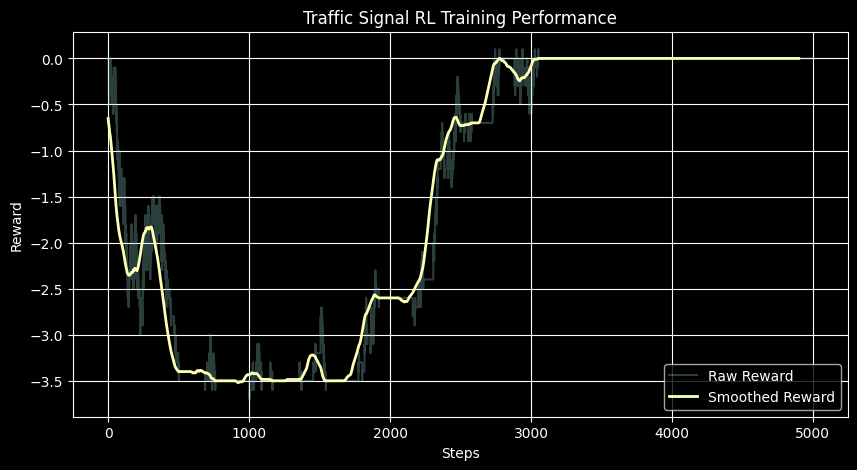

In [1]:
import traci
import os
import sys
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
import numpy as np

# CLEAN START
if traci.isLoaded():
    traci.close()

# SUMO SETUP
if 'SUMO_HOME' in os.environ:
    tools = os.path.join(os.environ['SUMO_HOME'], 'tools')
    sys.path.append(tools)
else:
    raise Exception("SUMO_HOME not set")

sumoBinary = "sumo-gui"
sumoCmd = [sumoBinary, "-c", "../sumo_files/simple.sumocfg"]

traci.start(sumoCmd)

tls = traci.trafficlight.getIDList()[0]
print("Using TLS:", tls)

# STATE
def get_state(tls_id):
    lanes = sorted(set(traci.trafficlight.getControlledLanes(tls_id)))

    state = []
    for lane in lanes:
        count = traci.lane.getLastStepVehicleNumber(lane)
        state.append(count / 10.0)

    return state

state_size = len(get_state(tls))
print("State size:", state_size)

# DQN MODEL
class DQN(nn.Module):
    def __init__(self, input_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 2)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Main model
model = DQN(state_size)

# Target model
target_model = DQN(state_size)
target_model.load_state_dict(model.state_dict())
target_model.eval()

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# MEMORY
memory = deque(maxlen=5000)

# PARAMETERS
gamma = 0.9
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.999

# ACTION
def choose_action(state):
    global epsilon

    if random.random() < epsilon:
        return random.choice([0, 1])

    state_tensor = torch.FloatTensor([state])
    q_values = model(state_tensor)

    return torch.argmax(q_values).item()

# REPLAY
def replay():
    if len(memory) < 32:
        return

    batch = random.sample(memory, 32)

    states = torch.FloatTensor([s for s, _, _, _ in batch])
    actions = torch.LongTensor([a for _, a, _, _ in batch])
    rewards = torch.FloatTensor([r for _, _, r, _ in batch])
    next_states = torch.FloatTensor([ns for _, _, _, ns in batch])

    q_values = model(states)
    next_q_values = target_model(next_states)
    max_next_q = torch.max(next_q_values, dim=1)[0]

    target = q_values.clone().detach()

    for i in range(len(batch)):
        target[i][actions[i]] = rewards[i] + gamma * max_next_q[i]

    loss = loss_fn(q_values, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# ---------------- SIMULATION ----------------
current_phase = 0

# Min green constraint
min_green = 10
last_switch = 0

# Track previous traffic
prev_total = 0

#LOG REWARDS
rewards_log = []

print("Running FINAL DQN with GRAPH...")

for step in range(5000):
    traci.simulationStep()

    state = get_state(tls)
    total = sum(state)

    # Action every few steps
    if step % 5 == 0:
        action = choose_action(state)
    else:
        action = 0

    # Apply action
    if action == 1 and (step - last_switch) > min_green:
        current_phase = 2 if current_phase == 0 else 0
        traci.trafficlight.setPhase(tls, current_phase)
        last_switch = step

    # Reward
    improvement = prev_total - total
    reward = improvement - total

    prev_total = total
    next_state = get_state(tls)

    # Store
    memory.append((state, action, reward, next_state))

    # Train
    replay()

    # Update target network
    if step % 100 == 0:
        target_model.load_state_dict(model.state_dict())

    # Decay epsilon
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

    # Store reward
    rewards_log.append(reward)

    if step % 100 == 0:
        print(f"Step: {step} | State: {state} | Reward: {reward:.2f} | Epsilon: {epsilon:.3f}")

traci.close()

# PLOT GRAPH
plt.figure(figsize=(10,5))

# Raw rewards
plt.plot(rewards_log, alpha=0.3, label="Raw Reward")

# Smoothed rewards
window = 100
if len(rewards_log) >= window:
    smooth = np.convolve(rewards_log, np.ones(window)/window, mode='valid')
    plt.plot(smooth, label="Smoothed Reward", linewidth=2)

plt.title("Traffic Signal RL Training Performance")
plt.xlabel("Steps")
plt.ylabel("Reward")
plt.legend()
plt.grid()

plt.show()